In [ ]:
# Cell 1 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import time

# Plot style
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f9fa"
plt.rcParams["axes.grid"]        = True
plt.rcParams["grid.alpha"]       = 0.3

CELL_COL      = "CO_DN"
CONTAMINATION = 0.05
RANDOM_STATE  = 42

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate",
        "threshold": 0.5,
        "direction": "high",
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR",
        "threshold": 99.5,
        "direction": "low",
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR",
        "threshold": 99.5,
        "direction": "low",
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "threshold": 7.0,
        "direction": "low",
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr",
        "threshold": 3.0,
        "direction": "low",
    },
]

KPI_COLS = [k["col"] for k in KPI_CONFIG]
print("✅ Imports done")

✅ Imports done


In [2]:
# Cell 2 – Load cleaned data
import pyxlsb

CSV_PATH = "../data/cleaned_master_data.csv"
RAW_FILE = "../data/4G raw KPI Cell wise17th_June'26.xlsb"

df = pd.read_csv(CSV_PATH)

# Ensure Short_Cell exists
if "Short_Cell" not in df.columns:
    df["Short_Cell"] = df[CELL_COL].apply(short_cell_name)

# Convert KPIs to numeric
for col in KPI_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Get sheet names for day ordering
with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets

print(f"Data shape        : {df.shape}")
print(f"Unique cells      : {df['Short_Cell'].nunique()}")
print(f"Days              : {df['Day'].nunique()}")
print(f"\nKPIs available:")
for cfg in KPI_CONFIG:
    exists = "✅" if cfg["col"] in df.columns else "❌"
    print(f"  {exists}  {cfg['label']:<15}  {cfg['col']}")

Data shape        : (842125, 97)
Unique cells      : 51359
Days              : 17

KPIs available:
  ✅  Drop Rate        ERAB Drop Rate_Radio_Nokia_VeMr
  ✅  E2E CSSR         E2E Call Setup Success Rate_Nokia_VeMr
  ✅  VoLTE CSSR       VoLTE Call Setup Success Rate_Nokia_VeMr
  ✅  CQI              Average CQI_Nokia_VeMr
  ✅  Avg Thpr         Nokia_LTE_DL_User_Throughput_Mbps


In [3]:
# Cell 3 – Build feature matrix for Isolation Forest
# Strategy: cell-level aggregation across all 17 days
# Each row = one unique cell
# Features = mean, std, min, max of each KPI across days

kpi_present = [c for c in KPI_COLS if c in df.columns]

# Aggregate per cell
cell_agg = df.groupby("Short_Cell")[kpi_present].agg([
    "mean", "std", "min", "max"
]).reset_index()

# Flatten column names
cell_agg.columns = [
    "_".join(c).strip("_") if isinstance(c, tuple) else c
    for c in cell_agg.columns
]

# Add breach count features
for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    if cfg["direction"] == "high":
        breach = df.groupby("Short_Cell")[col].apply(
            lambda x: (pd.to_numeric(x, errors="coerce") > cfg["threshold"]).sum()
        )
    else:
        breach = df.groupby("Short_Cell")[col].apply(
            lambda x: (pd.to_numeric(x, errors="coerce") < cfg["threshold"]).sum()
        )
    cell_agg[f"{cfg['label']}_breach_days"] = (
        cell_agg["Short_Cell"].map(breach).fillna(0)
    )

# Total breach days
breach_cols = [c for c in cell_agg.columns if c.endswith("_breach_days")]
cell_agg["total_breach_days"] = cell_agg[breach_cols].sum(axis=1)
cell_agg["kpis_breached"]     = (cell_agg[breach_cols] > 0).sum(axis=1)

print(f"Feature matrix shape : {cell_agg.shape}")
print(f"Unique cells         : {cell_agg['Short_Cell'].nunique()}")
print(f"Features             : {cell_agg.shape[1] - 1}")
print(f"\nFeature columns:")
for c in cell_agg.columns[1:]:
    print(f"  {c}")

Feature matrix shape : (51359, 28)
Unique cells         : 51359
Features             : 27

Feature columns:
  ERAB Drop Rate_Radio_Nokia_VeMr_mean
  ERAB Drop Rate_Radio_Nokia_VeMr_std
  ERAB Drop Rate_Radio_Nokia_VeMr_min
  ERAB Drop Rate_Radio_Nokia_VeMr_max
  E2E Call Setup Success Rate_Nokia_VeMr_mean
  E2E Call Setup Success Rate_Nokia_VeMr_std
  E2E Call Setup Success Rate_Nokia_VeMr_min
  E2E Call Setup Success Rate_Nokia_VeMr_max
  VoLTE Call Setup Success Rate_Nokia_VeMr_mean
  VoLTE Call Setup Success Rate_Nokia_VeMr_std
  VoLTE Call Setup Success Rate_Nokia_VeMr_min
  VoLTE Call Setup Success Rate_Nokia_VeMr_max
  Average CQI_Nokia_VeMr_mean
  Average CQI_Nokia_VeMr_std
  Average CQI_Nokia_VeMr_min
  Average CQI_Nokia_VeMr_max
  Nokia_LTE_DL_User_Throughput_Mbps_mean
  Nokia_LTE_DL_User_Throughput_Mbps_std
  Nokia_LTE_DL_User_Throughput_Mbps_min
  Nokia_LTE_DL_User_Throughput_Mbps_max
  Drop Rate_breach_days
  E2E CSSR_breach_days
  VoLTE CSSR_breach_days
  CQI_breach_days
 

In [4]:
# Cell 4 – Scale features for Isolation Forest

feature_cols = [c for c in cell_agg.columns if c != "Short_Cell"]
X_raw        = cell_agg[feature_cols].copy()

# Drop columns with too many missing values
missing_pct  = X_raw.isnull().mean()
X_raw        = X_raw.loc[:, missing_pct < 0.3]
feature_cols = X_raw.columns.tolist()

# Fill remaining NaN with median
X_raw = X_raw.fillna(X_raw.median())

# RobustScaler — better than StandardScaler for outlier-heavy telecom data
# Uses IQR instead of std deviation — not affected by extreme values
scaler = RobustScaler()
X      = scaler.fit_transform(X_raw)
X_df   = pd.DataFrame(X, columns=feature_cols)

print(f"Feature matrix : {X.shape}")
print(f"Scaler         : RobustScaler (IQR-based)")
print(f"\nFeature stats after scaling:")
print(pd.DataFrame(X, columns=feature_cols).describe().round(3).T[
    ["mean","std","min","max"]
].to_string())

Feature matrix : (51359, 27)
Scaler         : RobustScaler (IQR-based)

Feature stats after scaling:
                                                mean     std      min      max
ERAB Drop Rate_Radio_Nokia_VeMr_mean           0.403   2.478   -0.989  133.974
ERAB Drop Rate_Radio_Nokia_VeMr_std            0.580   4.195   -0.833  663.532
ERAB Drop Rate_Radio_Nokia_VeMr_min            0.330   2.329   -0.800  146.200
ERAB Drop Rate_Radio_Nokia_VeMr_max            0.491   2.945   -0.931  343.897
E2E Call Setup Success Rate_Nokia_VeMr_mean   -0.518   2.371 -150.365   10.216
E2E Call Setup Success Rate_Nokia_VeMr_std     1.038   6.892   -0.582  208.378
E2E Call Setup Success Rate_Nokia_VeMr_min    -0.827   4.584 -105.713    0.606
E2E Call Setup Success Rate_Nokia_VeMr_max    -0.466   2.583 -153.235  385.059
VoLTE Call Setup Success Rate_Nokia_VeMr_mean -0.835  11.575 -452.501    0.856
VoLTE Call Setup Success Rate_Nokia_VeMr_std   1.243  10.789   -0.878  275.530
VoLTE Call Setup Success Rate_

In [5]:
# Cell 5 – Train Isolation Forest

print("Training Isolation Forest...")
start = time.time()

model = IsolationForest(
    n_estimators  = 200,        # number of trees
    contamination = CONTAMINATION,  # expected % of outliers
    max_features  = 0.8,        # use 80% of features per tree
    bootstrap     = True,       # sample with replacement
    random_state  = RANDOM_STATE,
    n_jobs        = -1          # use all CPU cores
)
model.fit(X)

elapsed = round(time.time() - start, 2)

# Predict
cell_agg["anomaly_flag"]  = model.predict(X)      # -1=outlier, 1=normal
cell_agg["anomaly_score"] = model.score_samples(X) # more negative = worse

n_outliers = (cell_agg["anomaly_flag"] == -1).sum()
n_normal   = (cell_agg["anomaly_flag"] ==  1).sum()

print(f"\nTraining complete in {elapsed}s")
print(f"\nResults:")
print(f"  Total cells   : {len(cell_agg)}")
print(f"  Outliers (-1) : {n_outliers}  ({n_outliers/len(cell_agg)*100:.1f}%)")
print(f"  Normal   (+1) : {n_normal}   ({n_normal/len(cell_agg)*100:.1f}%)")
print(f"\nAnomaly score range:")
print(f"  Min : {cell_agg['anomaly_score'].min():.4f}  (most anomalous)")
print(f"  Max : {cell_agg['anomaly_score'].max():.4f}  (most normal)")
print(f"  Mean: {cell_agg['anomaly_score'].mean():.4f}")

Training Isolation Forest...

Training complete in 1.91s

Results:
  Total cells   : 51359
  Outliers (-1) : 2568  (5.0%)
  Normal   (+1) : 48791   (95.0%)

Anomaly score range:
  Min : -0.7843  (most anomalous)
  Max : -0.3331  (most normal)
  Mean: -0.3938


In [6]:
# Cell 6 – Evaluate quality using Silhouette Score
# Measures how well separated outliers are from normal cells
# Range: -1 (worst) to +1 (best)
# Higher = outliers are clearly distinct from normal cluster

try:
    sil_score = silhouette_score(
        X,
        cell_agg["anomaly_flag"],
        sample_size = 500,
        random_state = RANDOM_STATE
    )
    print(f"Silhouette Score : {sil_score:.4f}")
    if sil_score > 0.5:
        print("  → ✅ Strong separation between outliers and normal cells")
    elif sil_score > 0.25:
        print("  → ⚠️  Moderate separation")
    else:
        print("  → ❌ Weak separation — consider tuning contamination")
except Exception as e:
    print(f"Could not compute silhouette: {e}")

Silhouette Score : 0.8434
  → ✅ Strong separation between outliers and normal cells


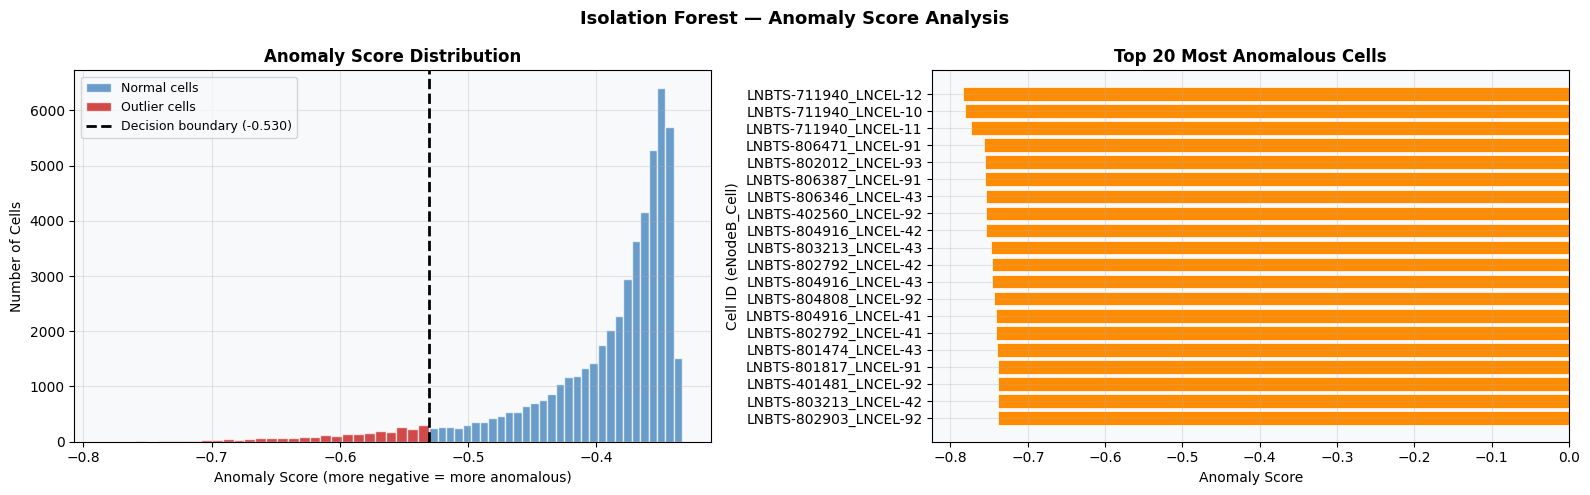

✅ Saved → outputs/if_anomaly_scores.png


In [7]:
# Cell 7 – Visualize anomaly score distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Isolation Forest — Anomaly Score Analysis",
             fontsize=13, fontweight="bold")

# Plot 1 — Score distribution
ax1 = axes[0]
normal_scores  = cell_agg[cell_agg["anomaly_flag"] ==  1]["anomaly_score"]
outlier_scores = cell_agg[cell_agg["anomaly_flag"] == -1]["anomaly_score"]

ax1.hist(normal_scores,  bins=30, color="#2E75B6",
         alpha=0.7, label="Normal cells",  edgecolor="white")
ax1.hist(outlier_scores, bins=30, color="#C00000",
         alpha=0.7, label="Outlier cells", edgecolor="white")

threshold_score = cell_agg[
    cell_agg["anomaly_flag"] == -1
]["anomaly_score"].max()

ax1.axvline(threshold_score, color="black", linestyle="--",
            linewidth=2, label=f"Decision boundary ({threshold_score:.3f})")
ax1.set_title("Anomaly Score Distribution", fontweight="bold")
ax1.set_xlabel("Anomaly Score (more negative = more anomalous)")
ax1.set_ylabel("Number of Cells")
ax1.legend(fontsize=9)

# Plot 2 — Top 20 most anomalous cells
ax2 = axes[1]
top20 = (cell_agg[cell_agg["anomaly_flag"] == -1]
         .sort_values("anomaly_score")
         .head(20))

colors = ["#C00000" if s < threshold_score * 1.5
          else "#FF8C00" for s in top20["anomaly_score"]]

ax2.barh(
    top20["Short_Cell"][::-1],
    top20["anomaly_score"][::-1],
    color=colors[::-1],
    edgecolor="white", linewidth=0.5
)
ax2.set_title("Top 20 Most Anomalous Cells", fontweight="bold")
ax2.set_xlabel("Anomaly Score")
ax2.set_ylabel("Cell ID (eNodeB_Cell)")

plt.tight_layout()
plt.savefig("../outputs/if_anomaly_scores.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/if_anomaly_scores.png")

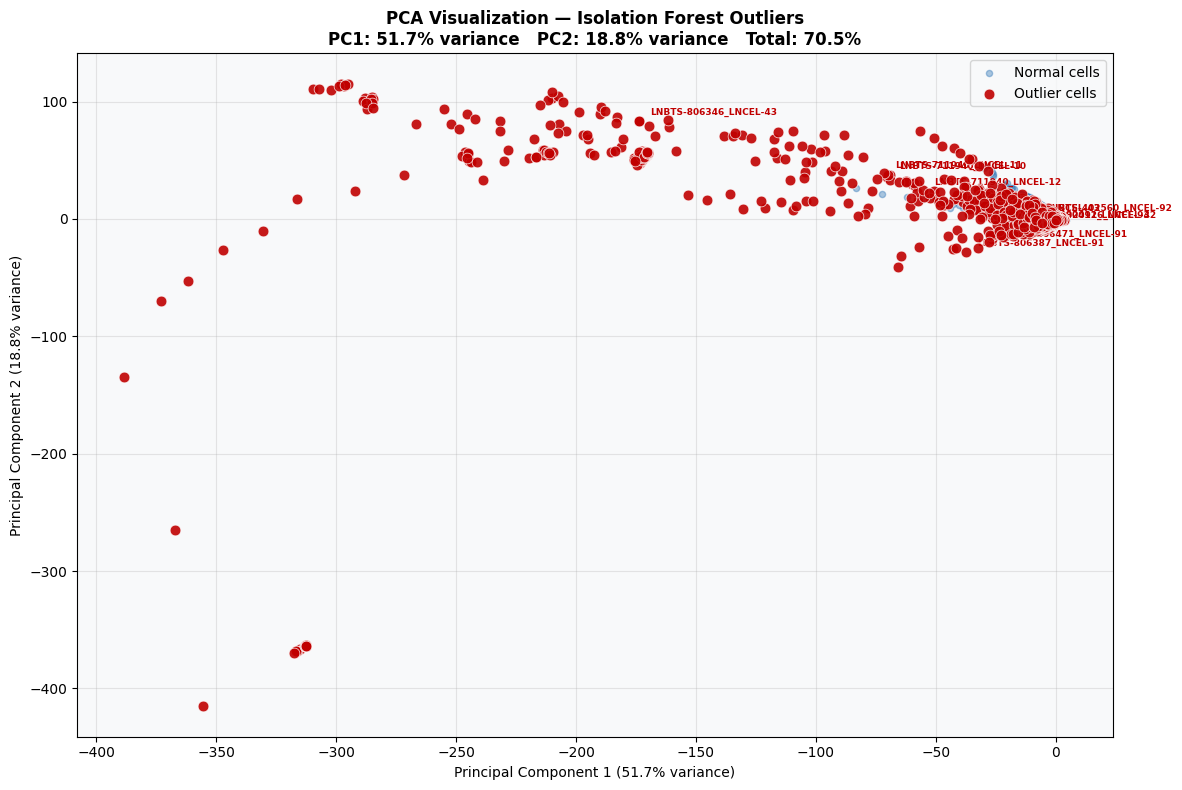

✅ Saved → outputs/if_pca_visualization.png


In [8]:
# Cell 8 – Visualize outliers in 2D using PCA

pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
var   = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(12, 8))

normal_mask  = cell_agg["anomaly_flag"] ==  1
outlier_mask = cell_agg["anomaly_flag"] == -1

ax.scatter(X_pca[normal_mask,  0], X_pca[normal_mask,  1],
           c="#2E75B6", alpha=0.4, s=20, label="Normal cells")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="#C00000", alpha=0.9, s=60, label="Outlier cells",
           zorder=5, edgecolors="white", linewidth=0.5)

# Label top 10 worst
top10 = (cell_agg[outlier_mask]
         .sort_values("anomaly_score")
         .head(10))
top10_idx = top10.index.tolist()

for idx in top10_idx:
    ax.annotate(
        cell_agg.loc[idx, "Short_Cell"],
        (X_pca[idx, 0], X_pca[idx, 1]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=6.5,
        color="#C00000",
        fontweight="bold"
    )

ax.set_title(
    f"PCA Visualization — Isolation Forest Outliers\n"
    f"PC1: {var[0]*100:.1f}% variance   "
    f"PC2: {var[1]*100:.1f}% variance   "
    f"Total: {sum(var)*100:.1f}%",
    fontweight="bold", fontsize=12
)
ax.set_xlabel(f"Principal Component 1 ({var[0]*100:.1f}% variance)")
ax.set_ylabel(f"Principal Component 2 ({var[1]*100:.1f}% variance)")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/if_pca_visualization.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/if_pca_visualization.png")

Computing feature importance (permutation)...


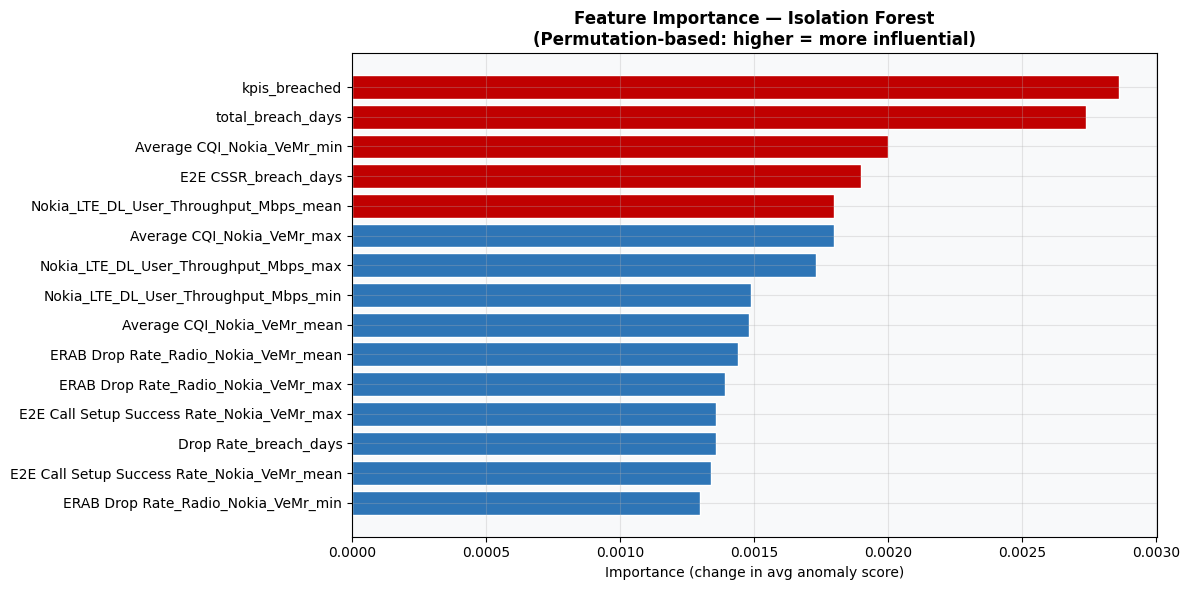


Top 10 most important features:
                               Feature  Importance
                         kpis_breached     0.00286
                     total_breach_days     0.00274
            Average CQI_Nokia_VeMr_min     0.00200
                  E2E CSSR_breach_days     0.00190
Nokia_LTE_DL_User_Throughput_Mbps_mean     0.00180
            Average CQI_Nokia_VeMr_max     0.00180
 Nokia_LTE_DL_User_Throughput_Mbps_max     0.00173
 Nokia_LTE_DL_User_Throughput_Mbps_min     0.00149
           Average CQI_Nokia_VeMr_mean     0.00148
  ERAB Drop Rate_Radio_Nokia_VeMr_mean     0.00144


In [9]:
# Cell 9 – Which features drive anomaly detection most?
# Permutation-based importance:
# Shuffle one feature at a time → measure how much scores change
# Bigger change = more important feature

from sklearn.inspection import permutation_importance

# Wrap IF in sklearn-compatible way
class IFWrapper:
    def __init__(self, model):
        self.model = model
    def fit(self, X, y=None):
        return self
    def score(self, X, y=None):
        return self.model.score_samples(X).mean()

print("Computing feature importance (permutation)...")
base_score = model.score_samples(X).mean()

importances = []
for i, feat in enumerate(feature_cols):
    X_permuted      = X.copy()
    X_permuted[:, i]= np.random.permutation(X_permuted[:, i])
    perm_score      = model.score_samples(X_permuted).mean()
    importances.append({
        "Feature"   : feat,
        "Importance": round(abs(base_score - perm_score), 5)
    })

imp_df = (pd.DataFrame(importances)
          .sort_values("Importance", ascending=False)
          .head(15)
          .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 6))
colors  = ["#C00000" if i < 5 else "#2E75B6"
           for i in range(len(imp_df))]

ax.barh(imp_df["Feature"][::-1],
        imp_df["Importance"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set_title("Feature Importance — Isolation Forest\n"
             "(Permutation-based: higher = more influential)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Importance (change in avg anomaly score)")
plt.tight_layout()
plt.savefig("../outputs/if_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 most important features:")
print(imp_df.head(10).to_string(index=False))

In [10]:
# Cell 10 – Run Isolation Forest per day separately
# Captures day-specific anomalies that cell-level avg might miss

daily_outliers = {}

for sheet in sheet_names:
    day_df = df[df["Day"] == sheet].copy().reset_index(drop=True)
    if day_df.empty:
        continue

    kpi_present = [c for c in KPI_COLS if c in day_df.columns]
    data = day_df[kpi_present].apply(
        pd.to_numeric, errors="coerce"
    ).fillna(day_df[kpi_present].apply(
        pd.to_numeric, errors="coerce"
    ).median())

    if data.shape[0] < 10:
        continue

    scaled = RobustScaler().fit_transform(data)

    day_model = IsolationForest(
        n_estimators  = 100,
        contamination = CONTAMINATION,
        random_state  = RANDOM_STATE,
        n_jobs        = -1
    )
    day_model.fit(scaled)

    day_df["anomaly_flag"]  = day_model.predict(scaled)
    day_df["anomaly_score"] = day_model.score_samples(scaled).round(6)

    outliers = day_df[day_df["anomaly_flag"] == -1].copy()
    daily_outliers[sheet] = outliers

    print(f"  {sheet[:35]:<35}  "
          f"total={len(day_df)}  "
          f"outliers={len(outliers)}")

total_outlier_events = sum(len(v) for v in daily_outliers.values())
print(f"\n✅ Per-day IF complete")
print(f"   Total outlier cell-day events: {total_outlier_events}")

  1st June_Cell Wise_4G                total=48779  outliers=2439
  2nd June_Cell Wise_4G                total=48796  outliers=2440
  3rd June_Cell Wise_4G                total=48796  outliers=2440
  4th June_Cell Wise_4G                total=49876  outliers=2494
  5th June_Cell Wise_4G                total=49795  outliers=2490
  6th June_Cell Wise_4G                total=49733  outliers=2487
  7th June_Cell Wise_4G                total=49874  outliers=2494
  8th June_Cell Wise_4G                total=48796  outliers=2440
  9th June_Cell Wise_4G                total=49724  outliers=2487
  10th June_Cell Wise_4G               total=49705  outliers=2486
  11th June_Cell Wise_4G               total=49705  outliers=2486
  12th June_Cell Wise_4G               total=49812  outliers=2491
  13th June_Cell Wise_4G               total=49717  outliers=2486
  14th June_Cell Wise_4G               total=49689  outliers=2485
  15th June_Cell Wise_4G               total=49776  outliers=2489
  16th Jun

In [11]:
# Cell 11 – Save all results

# 1. Cell-level anomaly results (17-day aggregated)
cell_output = cell_agg[[
    "Short_Cell",
    "anomaly_flag",
    "anomaly_score",
    "total_breach_days",
    "kpis_breached"
] + [c for c in cell_agg.columns if c.endswith("_mean")]
].copy()

cell_output.to_csv(
    "../outputs/cell_anomaly_results.csv",
    index=False
)
print(f"✅ Saved → outputs/cell_anomaly_results.csv")
print(f"   Shape: {cell_output.shape}")

# 2. Per-day outlier results
all_daily = pd.concat(daily_outliers.values(), ignore_index=True)
all_daily[[
    "Short_Cell", CELL_COL, "Day",
    "anomaly_flag", "anomaly_score"
] + [c for c in KPI_COLS if c in all_daily.columns]
].to_csv(
    "../outputs/daily_outlier_events.csv",
    index=False
)
print(f"\n✅ Saved → outputs/daily_outlier_events.csv")
print(f"   Shape: {all_daily.shape}")

# 3. Priority cells — flagged by both methods
cell_level_outliers = set(
    cell_agg[cell_agg["anomaly_flag"] == -1]["Short_Cell"]
)
daily_level_outliers = set(all_daily["Short_Cell"].unique())
both_flagged = cell_level_outliers & daily_level_outliers

priority = cell_agg[
    cell_agg["Short_Cell"].isin(both_flagged)
].sort_values("anomaly_score")[["Short_Cell","anomaly_score",
                                 "total_breach_days","kpis_breached"]]

priority.to_csv("../outputs/priority_cells.csv", index=False)
print(f"\n✅ Saved → outputs/priority_cells.csv")
print(f"   Priority cells (flagged by both methods): {len(priority)}")

✅ Saved → outputs/cell_anomaly_results.csv
   Shape: (51359, 10)

✅ Saved → outputs/daily_outlier_events.csv
   Shape: (42112, 99)

✅ Saved → outputs/priority_cells.csv
   Priority cells (flagged by both methods): 2502


In [12]:
# Cell 11 – Save all results

# 1. Cell-level anomaly results (17-day aggregated)
cell_output = cell_agg[[
    "Short_Cell",
    "anomaly_flag",
    "anomaly_score",
    "total_breach_days",
    "kpis_breached"
] + [c for c in cell_agg.columns if c.endswith("_mean")]
].copy()

cell_output.to_csv(
    "../outputs/cell_anomaly_results.csv",
    index=False
)
print(f"✅ Saved → outputs/cell_anomaly_results.csv")
print(f"   Shape: {cell_output.shape}")

# 2. Per-day outlier results
all_daily = pd.concat(daily_outliers.values(), ignore_index=True)
all_daily[[
    "Short_Cell", CELL_COL, "Day",
    "anomaly_flag", "anomaly_score"
] + [c for c in KPI_COLS if c in all_daily.columns]
].to_csv(
    "../outputs/daily_outlier_events.csv",
    index=False
)
print(f"\n✅ Saved → outputs/daily_outlier_events.csv")
print(f"   Shape: {all_daily.shape}")

# 3. Priority cells — flagged by both methods
cell_level_outliers = set(
    cell_agg[cell_agg["anomaly_flag"] == -1]["Short_Cell"]
)
daily_level_outliers = set(all_daily["Short_Cell"].unique())
both_flagged = cell_level_outliers & daily_level_outliers

priority = cell_agg[
    cell_agg["Short_Cell"].isin(both_flagged)
].sort_values("anomaly_score")[["Short_Cell","anomaly_score",
                                 "total_breach_days","kpis_breached"]]

priority.to_csv("../outputs/priority_cells.csv", index=False)
print(f"\n✅ Saved → outputs/priority_cells.csv")
print(f"   Priority cells (flagged by both methods): {len(priority)}")

✅ Saved → outputs/cell_anomaly_results.csv
   Shape: (51359, 10)

✅ Saved → outputs/daily_outlier_events.csv
   Shape: (42112, 99)

✅ Saved → outputs/priority_cells.csv
   Priority cells (flagged by both methods): 2502


In [13]:
# Cell 12 – Final summary

print("=" * 60)
print("ISOLATION FOREST SUMMARY")
print("=" * 60)
print(f"\nModel Configuration:")
print(f"  n_estimators  : 200")
print(f"  contamination : {CONTAMINATION} ({CONTAMINATION*100:.0f}%)")
print(f"  max_features  : 0.8")
print(f"  scaler        : RobustScaler")

print(f"\nCell-Level Results (17-day aggregated):")
print(f"  Total cells   : {len(cell_agg)}")
print(f"  Outliers      : {(cell_agg['anomaly_flag']==-1).sum()}")
print(f"  Normal        : {(cell_agg['anomaly_flag']==1).sum()}")

print(f"\nPer-Day Results:")
print(f"  Days processed   : {len(daily_outliers)}")
print(f"  Total events     : {total_outlier_events}")
print(f"  Avg per day      : {total_outlier_events/len(daily_outliers):.1f}")

print(f"\nPriority Cells (both methods agree): {len(priority)}")

print(f"\nOutput Files:")
for f in ["cell_anomaly_results.csv",
          "daily_outlier_events.csv",
          "priority_cells.csv"]:
    path = f"../outputs/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists}  {f}")

ISOLATION FOREST SUMMARY

Model Configuration:
  n_estimators  : 200
  contamination : 0.05 (5%)
  max_features  : 0.8
  scaler        : RobustScaler

Cell-Level Results (17-day aggregated):
  Total cells   : 51359
  Outliers      : 2568
  Normal        : 48791

Per-Day Results:
  Days processed   : 17
  Total events     : 42112
  Avg per day      : 2477.2

Priority Cells (both methods agree): 2502

Output Files:


NameError: name 'os' is not defined